<a href="https://colab.research.google.com/github/GitGirlie27/urdu-ocr-codesaviours-si26-Amna/blob/main/SI26_Week5_Amna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WEEK 5 NOTEBOOK**

# *Install Packages*

In [ ]:
!pip install -q transformers sentencepiece protobuf torch pillow pandas opencv-python-headless jiwer gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.5 MB/s eta 0:00:00


# *Import Zip File*

In [ ]:
import zipfile

zip_path = "/content/Urdu OCR Dataset.zip"
extract_path = "/content/Urdu_OCR_Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# *Install Libraries*

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print('Libraries loaded successfully!')

Using device: cuda
Libraries loaded successfully!


# *Image Preprocessing Techniques*

In [ ]:
def preprocess_image(image_path, save_path=None):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Convert to Grayscale for contrast enhancement, then back to RGB
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Mild CLAHE to sharpen text contrast without creating binary noise
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Convert back to 3-channel RGB image required by Vision Transformer
    rgb_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

    return rgb_img

# *Process Entire Dataset*

In [ ]:
input_folder = "/content/Urdu_OCR_Dataset/Urdu OCR Dataset"
output_folder = "/content/processed"

os.makedirs(output_folder, exist_ok=True)
image_paths = sorted(glob.glob(os.path.join(input_folder, "*.png")))

print(f"Total PNG images found: {len(image_paths)}")

for image_path in image_paths:
    filename = os.path.basename(image_path)
    save_path = os.path.join(output_folder, filename)
    preprocess_image(image_path, save_path)

print("Preprocessing completed successfully!")

Total PNG images found: 209
Preprocessing completed successfully!


# *Display Image Before and After Processing*

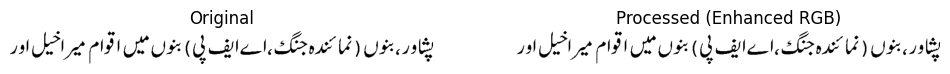

In [ ]:
if len(image_paths) > 0:
    filename = os.path.basename(image_paths[0])

    original = cv2.imread(os.path.join(input_folder, filename))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    processed = cv2.imread(os.path.join(output_folder, filename))
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed)
    plt.title("Processed (Enhanced RGB)")
    plt.axis("off")
    plt.show()

# *Check CSV File Created*

In [ ]:
import pandas as pd
import chardet

csv_path = "/content/Labels csv.csv"

# 1. Detect the exact file encoding automatically
with open(csv_path, "rb") as f:
    raw_data = f.read(100000)  # Read a sample chunk
    result = chardet.detect(raw_data)
    detected_encoding = result["encoding"]

print(f"Detected encoding: {detected_encoding}")

# 2. Read the CSV using the detected encoding
df = pd.read_csv(csv_path, encoding=detected_encoding)

print("CSV Columns:", df.columns.tolist())
print("\nFirst 3 rows sample (Urdu text should now display properly):")
print(df.head(10))

Detected encoding: UTF-8-SIG
CSV Columns: ['Image_no', 'Text']

First 3 rows sample (Urdu text should now display properly):
                   Image_no                                               Text
0  /content/processed/0.png  پشاور، بنوں (نما ئندہ جنگ، اے ایف پی) بنوں میں...
1  /content/processed/1.png        اسکے ساتھ ملحقہ علاقے کے عوام نے بجلی و گیس
2  /content/processed/2.png  کی لوڈشیڈنگ کیخلاف مظاہرہ کیا۔ پولیس تشدد سے ا...
3  /content/processed/3.png  منشور علی جاں بحق اور 2 خواتین سمیت 14 افراد ز...
4  /content/processed/4.png  علاقے میں کرفیو نافذ کر دیا گیا ہے۔ مکینوں نے ...
5  /content/processed/5.png     لگایا کہ پولیس کی فائرنگ سے شہری ہلاک ہوا جبکہ
6  /content/processed/6.png          پولیس کا کہنا ہے کہ مظاہرین میں کسی نے ہم
7  /content/processed/7.png     پر براہ راست فائرنگ کی اور فائرنگ کے تبادلے کے
8  /content/processed/8.png  نتیجے میں ایک شہری ہلاک ہو گیا۔ تفصیلات کے مطا...
9  /content/processed/9.png  میں اقوام میر اخیل اور اسکے ساتھ ملحقہ علاقے ک...


# *Build the Dataset Class*

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class UrduOCRDataset(Dataset):
    def __init__(self, csv_file, processor, max_target_length=128):
        self.processor = processor
        self.max_target_length = max_target_length

        # Load CSV using UTF-8 saved directly from Excel
        self.data = pd.read_csv(csv_file, encoding="utf-8-sig")

        # Strip trailing/leading spaces from column names to prevent KeyErrors
        self.data.columns = self.data.columns.str.strip()

        # Verify columns exist or try matching case-insensitively
        cols = {c.lower(): c for c in self.data.columns}
        img_col = cols.get("image_no", "Image_no")
        text_col = cols.get("text", "Text")

        # Map full image paths safely
        self.data["Full_Image_Path"] = self.data[img_col].apply(
            lambda x: os.path.join("/content/processed", str(x).strip())
        )

        # Keep track of text column name for later use
        self.text_col = text_col

        print(f"Dataset loaded successfully with {len(self.data)} samples!")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Open image using the full path
        image = Image.open(row["Full_Image_Path"]).convert("RGB")

        pixel_values = self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Retrieve text safely using the resolved column name
        text = str(row[self.text_col])

        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

# *Install Packages*

In [ ]:
!pip install -q transformers sentencepiece protobuf torch pillow pandas

# *Load Image Processor*

In [ ]:
from transformers import TrOCRProcessor, RobertaTokenizer, ViTImageProcessor

# 1. Manually load the underlying tokenizer and image processor
# (This bypasses the broken auto-instantiation code completely)
tokenizer = RobertaTokenizer.from_pretrained(
    "microsoft/trocr-base-printed"
)
image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')

# 2. Bundle them together into the TrOCRProcessor structure manually
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

print("Processor successfully loaded manually!")

Processor successfully loaded manually!


# *Test and Split Dataset*

In [ ]:
import torch

# Create dataset (moved keyword argument 'encoding' to the end)
dataset = UrduOCRDataset('/content/Labels csv.csv', processor)

# Replace 'dataset' with whatever name you gave your Dataset object
sample = dataset[0]

print('Sample pixel_values shape:', sample['pixel_values'].shape)
print('Sample labels shape:', sample['labels'].shape)
print('Dataset is working correctly!')

# Create train / test split (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)
print(f"Training samples: {train_size}")
print(f"Testing samples: {test_size}")

Dataset loaded successfully with 208 samples!
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([128])
Dataset is working correctly!
Training samples: 166
Testing samples: 42


# *Load Pretrained TrOCR Model*

In [ ]:
from transformers import ViTImageProcessor, RobertaTokenizer, TrOCRProcessor, VisionEncoderDecoderModel
import torch

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# 1. Load the vision component safely
image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')

# 2. Load a standard clean RoBERTa tokenizer (bypasses sentencepiece backend compilation)
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')

# 3. Construct the TrOCRProcessor manually by pairing the independent components
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

# 4. Load the core model architecture
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')
model = model.to(device)

# 5. Generation alignment configuration
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id

print('\n' + '='*50)
print('SUCCESS: Components assembled manually. The backend is completely bypassed!')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print('='*50)

Using device: cuda


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



SUCCESS: Components assembled manually. The backend is completely bypassed!
Model parameters: 333,921,792


# Create Dataloader

In [ ]:
from torch.utils.data import DataLoader
import torch

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(test_dataset, batch_size=4)

# Native PyTorch Optimizer (Clean and future-proof)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

print(f'Training batches per epoch: {len(train_loader)}')
print('Ready to train!')

Training batches per epoch: 42
Ready to train!


# *Set Up Training*

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    correct_tokens = 0
    total_tokens = 0

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-"*50)

    for batch_idx, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


        predictions = outputs.logits.argmax(dim=-1)

        mask = labels != -100

        correct_tokens += ((predictions == labels) & mask).sum().item()
        total_tokens += mask.sum().item()

        if batch_idx % 10 == 0:

            accuracy = 100 * correct_tokens / total_tokens

            print(
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Accuracy: {accuracy:.2f}%"
            )

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = 100 * correct_tokens / total_tokens

    print("\nEpoch Summary")
    print(f"Average Loss : {avg_loss:.4f}")
    print(f"Accuracy     : {epoch_accuracy:.2f}%")


Epoch 1/5
--------------------------------------------------
Batch 0/42 | Loss: 17.7618 | Accuracy: 0.86%
Batch 10/42 | Loss: 4.8344 | Accuracy: 6.67%
Batch 20/42 | Loss: 4.0306 | Accuracy: 7.34%
Batch 30/42 | Loss: 3.7613 | Accuracy: 8.14%
Batch 40/42 | Loss: 3.7886 | Accuracy: 8.57%

Epoch Summary
Average Loss : 5.1167
Accuracy     : 8.58%

Epoch 2/5
--------------------------------------------------
Batch 0/42 | Loss: 3.7746 | Accuracy: 8.62%
Batch 10/42 | Loss: 3.4786 | Accuracy: 9.73%
Batch 20/42 | Loss: 3.8244 | Accuracy: 9.83%
Batch 30/42 | Loss: 3.6699 | Accuracy: 9.97%
Batch 40/42 | Loss: 3.5815 | Accuracy: 10.03%

Epoch Summary
Average Loss : 3.6793
Accuracy     : 10.09%

Epoch 3/5
--------------------------------------------------
Batch 0/42 | Loss: 3.5304 | Accuracy: 10.28%
Batch 10/42 | Loss: 3.6590 | Accuracy: 10.78%
Batch 20/42 | Loss: 3.7759 | Accuracy: 10.61%
Batch 30/42 | Loss: 3.6352 | Accuracy: 10.46%
Batch 40/42 | Loss: 3.8117 | Accuracy: 10.47%

Epoch Summary
Ave

# Save Model

In [ ]:
model.save_pretrained("/content/urdu_trocr_model")
processor.save_pretrained("/content/urdu_trocr_model")

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


# Install Packages

In [ ]:
!pip install gradio transformers torch pillow

# Build Interface

In [ ]:
import gradio as gr
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

# Load your saved model from Drive
from google.colab import drive

drive.mount("/content/drive")

model_path = "/content/urdu_trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
model.eval()


def extract_urdu_text(image):
    """Takes an image, returns extracted Urdu text."""
    if image is None:
        return "Please upload an image"

    pixel_values = processor(image, return_tensors="pt").pixel_values
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text if text else "Could not extract text from this image"


# Build the interface
interface = gr.Interface(
    fn=extract_urdu_text,
    inputs=gr.Image(type="pil", label="Upload Urdu Image"),
    outputs=gr.Textbox(label="Extracted Urdu Text"),
    title="Urdu OCR -- Code Saviours SI-26",
    description="Upload an image containing Urdu text and get the extracted text.",
    examples=[],
)

interface.launch(share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd4a06311961c1bf56.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
